# Image Clustering Using Diffusion Maps

In [217]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/stl10")

print("Path to dataset files:", path)

Path to dataset files: /home/rp/.cache/kagglehub/datasets/jessicali9530/stl10/versions/3


# Phase 1 — Dataset Loading

**Link**: https://www.kaggle.com/datasets/jessicali9530/stl10

This phase loads and organizes the STL-10 image dataset.

The dataset is already downloaded using KaggleHub. We will use Python's
`pathlib` library to locate the image folders and collect the image file paths.

At this stage, we do not perform any mathematical processing. The purpose
of this phase is only to create an organized list of images that can be
used by later phases.

The three available parts of the dataset are:

- `train_images` — training images
- `test_images` — test images
- `unlabeled_images` — unlabeled images

The image files will be loaded in later phases when preprocessing is required.

In [218]:
from pathlib import Path
from typing import List

### Dataset Location

KaggleHub downloaded the STL-10 dataset to the following directory:

`/home/rp/.cache/kagglehub/datasets/jessicali9530/stl10/versions/3`

We will store this location in a variable so that we do not have to repeatedly
write the complete path throughout the notebook.

In [219]:
dataset_root_directory: Path = Path(path)

print("Dataset Root Directory:")
print(dataset_root_directory)

Dataset Root Directory:
/home/rp/.cache/kagglehub/datasets/jessicali9530/stl10/versions/3


### Dataset Directories

The STL-10 dataset contains three main image directories.

We create separate variables for each directory so their purpose is clear
from the variable name itself.

In [220]:
training_image_directory: Path = (dataset_root_directory / "train_images")
testing_image_directory: Path = (dataset_root_directory / "test_images")
unlabeled_image_directory: Path = (dataset_root_directory / "unlabeled_images")

print("Training Image Directory :", training_image_directory)
print("Testing Image Directory  :", testing_image_directory)
print("Unlabeled Image Directory:", unlabeled_image_directory)

Training Image Directory : /home/rp/.cache/kagglehub/datasets/jessicali9530/stl10/versions/3/train_images
Testing Image Directory  : /home/rp/.cache/kagglehub/datasets/jessicali9530/stl10/versions/3/test_images
Unlabeled Image Directory: /home/rp/.cache/kagglehub/datasets/jessicali9530/stl10/versions/3/unlabeled_images


### Collect Image File Paths

We need a function that receives an image directory and returns a list of
image files contained inside that directory.

This function does not load the images into memory yet.

It only finds their file locations.

This is important because the dataset contains a large number of images,
especially the 100,000 unlabeled images. Keeping only the file paths is much
more memory efficient than loading all images into memory at once.

In [221]:
def collect_image_file_paths(image_directory: Path) -> List[Path]:
    """
    Collect all PNG image file paths from a directory.

    Parameters
    ----------
    image_directory : Path
        Directory containing the image files.

    Returns
    -------
    List[Path]
        A list containing the paths of all PNG images
        found in the specified directory.
    """

    image_file_paths: List[Path] = sorted(image_directory.glob("*.png"))

    return image_file_paths

In [222]:
training_image_paths: List[Path] = (
    collect_image_file_paths(training_image_directory)
)

testing_image_paths: List[Path] = (
    collect_image_file_paths(testing_image_directory)
)

unlabeled_image_paths: List[Path] = (
    collect_image_file_paths(unlabeled_image_directory)
)

### Dataset Loading Result

We now verify that the image paths were successfully collected.

We will check:

1. Number of training images
2. Number of testing images
3. Number of unlabeled images
4. Total number of images
5. First and last file in each dataset

The purpose of this check is to make sure that the dataset was loaded
correctly before continuing to the next phase.

In [223]:
number_of_training_images: int = len(training_image_paths)
number_of_testing_images: int = len(testing_image_paths)
number_of_unlabeled_images: int = len(unlabeled_image_paths)

total_number_of_images: int = (
    number_of_training_images
    + number_of_testing_images
    + number_of_unlabeled_images
)

print("=" * 60)
print("PHASE 1 — DATASET LOADING RESULT")
print("=" * 60)

print(f"Training Images   : {number_of_training_images}")
print(f"Testing Images    : {number_of_testing_images}")
print(f"Unlabeled Images  : {number_of_unlabeled_images}")
print(f"Total Images      : {total_number_of_images}")

PHASE 1 — DATASET LOADING RESULT
Training Images   : 5000
Testing Images    : 8000
Unlabeled Images  : 100000
Total Images      : 113000


In [224]:
all_training_images_are_png: bool = all(
    image_path.suffix.lower() == ".png"
    for image_path in training_image_paths
)

all_testing_images_are_png: bool = all(
    image_path.suffix.lower() == ".png"
    for image_path in testing_image_paths
)

all_unlabeled_images_are_png: bool = all(
    image_path.suffix.lower() == ".png"
    for image_path in unlabeled_image_paths
)

print("=" * 60)
print("FILE FORMAT CHECK")
print("=" * 60)

print(
    "All training images are PNG   :",
    all_training_images_are_png
)

print(
    "All testing images are PNG    :",
    all_testing_images_are_png
)

print(
    "All unlabeled images are PNG  :",
    all_unlabeled_images_are_png
)

FILE FORMAT CHECK
All training images are PNG   : True
All testing images are PNG    : True
All unlabeled images are PNG  : True


## Phase 1 — Conclusion

The STL-10 dataset was successfully loaded and organized into three image
sets: training, testing, and unlabeled images.

The dataset contains 113,000 PNG images in total:

- 5,000 training images
- 8,000 testing images
- 100,000 unlabeled images

All three image directories were successfully located, and the collected
files were verified to have the PNG format.

At this stage, only image file paths were collected. The actual image pixels
will be loaded and converted into NumPy arrays during the preprocessing phase.

Keeping the image paths instead of loading the entire dataset into memory
allows the project to work with a selected subset of images during the
computationally expensive Diffusion Maps stages.

# Phase 2 — Dataset Exploration

## Libraries for Dataset Exploration

This phase uses libraries only for dataset inspection and visualization.

No algebraic processing is performed in this phase.

- `pathlib` is used to work with file paths.
- `PIL` is used to inspect image properties and open images.
- `pandas` is used to organize summary information.
- `matplotlib` is used to visualize sample images.

In [225]:
from pathlib import Path
from typing import List, Dict

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

### Combining Image Paths

The STL-10 dataset contains three separate image groups.

For dataset exploration, we combine their paths into one list so that we
can inspect the properties of the entire dataset using the same functions.

We still do not load all images into memory. Only the file paths are combined.

In [226]:
all_image_paths: List[Path] = (
    training_image_paths
    + testing_image_paths
    + unlabeled_image_paths
)

print("=" * 60)
print("COMBINED DATASET")
print("=" * 60)

print(f"Total Image Paths : {len(all_image_paths)}")

COMBINED DATASET
Total Image Paths : 113000


### Inspecting an Image

Before examining the entire dataset, we first create a simple function
that extracts the basic properties of one image.

The function reports:

- image filename
- image width and height
- color mode
- file format

This allows us to understand the structure of an individual image before
checking the complete dataset.

In [227]:
def inspect_single_image(
    image_path: Path
) -> Dict[str, object]:
    """
    Inspect the basic properties of one image.

    Parameters
    ----------
    image_path : Path
        Path to the image that will be inspected.

    Returns
    -------
    Dict[str, object]
        Dictionary containing the image filename, size, color mode,
        and file format.
    """

    with Image.open(image_path) as image:
        image_properties: Dict[str, object] = {
            "Filename": image_path.name,
            "Width": image.width,
            "Height": image.height,
            "Mode": image.mode,
            "Format": image.format
        }

    return image_properties

In [228]:
first_training_image_properties: Dict[str, object] = (
    inspect_single_image(training_image_paths[0])
)

print("=" * 60)
print("SINGLE IMAGE INSPECTION")
print("=" * 60)

for property_name, property_value in first_training_image_properties.items():
    print(f"{property_name:<10}: {property_value}")

SINGLE IMAGE INSPECTION
Filename  : train_image_png_1.png
Width     : 96
Height    : 96
Mode      : RGB
Format    : PNG


### Image Dimension Analysis

Diffusion Maps requires numerical representations of the images.

Before creating those representations, we need to know whether all images
have the same width and height.

We will inspect the dimensions of the images and identify all unique
(width, height) combinations.

To avoid loading every image into memory, each image is opened temporarily
and closed immediately after its properties are read.

In [229]:
def collect_image_dimensions(
    image_paths: List[Path]
) -> List[tuple[int, int]]:
    """
    Collect the width and height of every image.

    Parameters
    ----------
    image_paths : List[Path]
        List containing paths to the images.

    Returns
    -------
    List[tuple[int, int]]
        List containing (width, height) for each image.
    """

    image_dimensions: List[tuple[int, int]] = []

    for image_path in image_paths:
        with Image.open(image_path) as image:
            image_dimensions.append(
                (image.width, image.height)
            )

    return image_dimensions

In [230]:
all_image_dimensions: List[tuple[int, int]] = (
    collect_image_dimensions(all_image_paths)
)

unique_image_dimensions = sorted(
    set(all_image_dimensions)
)

print("=" * 60)
print("IMAGE DIMENSION ANALYSIS")
print("=" * 60)

print(
    f"Number of Unique Dimensions : "
    f"{len(unique_image_dimensions)}"
)

print("Unique Dimensions:")

for image_dimension in unique_image_dimensions:
    print(image_dimension)

IMAGE DIMENSION ANALYSIS
Number of Unique Dimensions : 1
Unique Dimensions:
(96, 96)


### Color Mode Analysis

Images can be stored using different color representations.

Examples include:

- RGB — three color channels
- L — grayscale
- RGBA — RGB plus transparency

Our feature representation will need a consistent structure.

Therefore, we check the color mode of all images.

In [231]:
def collect_image_color_modes(
    image_paths: List[Path]
) -> List[str]:
    """
    Collect the color mode of every image.

    Parameters
    ----------
    image_paths : List[Path]
        List containing image file paths.

    Returns
    -------
    List[str]
        Color mode of each image.
    """

    image_color_modes: List[str] = []

    for image_path in image_paths:
        with Image.open(image_path) as image:
            image_color_modes.append(image.mode)

    return image_color_modes

In [232]:
all_image_color_modes: List[str] = (
    collect_image_color_modes(all_image_paths)
)

unique_image_color_modes: Dict[str, int] = (
    pd.Series(all_image_color_modes)
    .value_counts()
    .to_dict()
)

print("=" * 60)
print("COLOR MODE ANALYSIS")
print("=" * 60)

for color_mode, image_count in unique_image_color_modes.items():
    print(
        f"{color_mode:<10}: {image_count}"
    )

COLOR MODE ANALYSIS
RGB       : 113000


### Image Format Analysis

The dataset filenames have the `.png` extension, but we should also verify
the actual internal image format reported by the image file.

This prevents us from assuming that the extension always represents the
real image format.

In [233]:
def collect_image_formats(
    image_paths: List[Path]
) -> List[str]:
    """
    Collect the actual image format of every image.

    Parameters
    ----------
    image_paths : List[Path]
        List containing image file paths.

    Returns
    -------
    List[str]
        Actual image format of each image.
    """

    image_formats: List[str] = []

    for image_path in image_paths:
        with Image.open(image_path) as image:
            image_formats.append(image.format)

    return image_formats

In [234]:
all_image_formats: List[str] = (
    collect_image_formats(all_image_paths)
)

image_format_counts: Dict[str, int] = (
    pd.Series(all_image_formats)
    .value_counts()
    .to_dict()
)

print("=" * 60)
print("IMAGE FORMAT ANALYSIS")
print("=" * 60)

for image_format, image_count in image_format_counts.items():
    print(
        f"{image_format:<10}: {image_count}"
    )

IMAGE FORMAT ANALYSIS
PNG       : 113000


### Corrupted Image Detection

An image file may exist but contain invalid or damaged image data.

We will verify every image using Pillow.

If an image cannot be successfully verified, its path will be added to a
list of corrupted images.

We will not modify the images during this process.

In [235]:
def find_corrupted_images(
    image_paths: List[Path]
) -> List[Path]:
    """
    Find images that cannot be successfully verified.

    Parameters
    ----------
    image_paths : List[Path]
        List containing image file paths.

    Returns
    -------
    List[Path]
        List containing paths of corrupted images.
    """

    corrupted_image_paths: List[Path] = []

    for image_path in image_paths:

        try:
            with Image.open(image_path) as image:
                image.verify()

        except Exception:
            corrupted_image_paths.append(image_path)

    return corrupted_image_paths

In [236]:
corrupted_image_paths: List[Path] = (
    find_corrupted_images(all_image_paths)
)

valid_image_count: int = (
    len(all_image_paths) - len(corrupted_image_paths)
)

corrupted_image_count: int = (
    len(corrupted_image_paths)
)

print("=" * 60)
print("CORRUPTED IMAGE REPORT")
print("=" * 60)

print(f"Valid Images     : {valid_image_count}")
print(f"Corrupted Images : {corrupted_image_count}")

CORRUPTED IMAGE REPORT
Valid Images     : 113000
Corrupted Images : 0


### Dataset Summary

The following table provides a high-level summary of the three STL-10
dataset sections.

This table is useful for documenting the dataset in the final report.

In [237]:
dataset_summary: pd.DataFrame = pd.DataFrame(
    {
        "Dataset Part": [
            "Training",
            "Testing",
            "Unlabeled"
        ],
        "Image Count": [
            len(training_image_paths),
            len(testing_image_paths),
            len(unlabeled_image_paths)
        ]
    }
)

print(dataset_summary)

  Dataset Part  Image Count
0     Training         5000
1      Testing         8000
2    Unlabeled       100000


### Sample Image Visualization

We will display a small number of randomly selected training images.

Visualization helps us understand:

- image appearance
- image quality
- variation between images
- background variation
- object positioning
- whether the images appear suitable for the project

This visualization is for exploration only. It does not perform mathematical
processing on the images.

In [238]:
def display_sample_images(
    image_paths: List[Path],
    number_of_images_to_display: int = 12
) -> None:
    """
    Display a sample of images from the dataset.

    Parameters
    ----------
    image_paths : List[Path]
        List containing image file paths.

    number_of_images_to_display : int
        Number of images to display.
    """

    selected_image_paths: List[Path] = (
        image_paths[:number_of_images_to_display]
    )

    number_of_columns: int = 4
    number_of_rows: int = (
        (len(selected_image_paths) + number_of_columns - 1)
        // number_of_columns
    )

    figure, axes = plt.subplots(
        number_of_rows,
        number_of_columns,
        figsize=(12, 9)
    )

    axes = axes.flatten()

    for image_index, image_path in enumerate(
        selected_image_paths
    ):

        with Image.open(image_path) as image:
            axes[image_index].imshow(image)

        axes[image_index].set_title(
            image_path.name,
            fontsize=8
        )

        axes[image_index].axis("off")

    for unused_axis in axes[len(selected_image_paths):]:
        unused_axis.axis("off")

    plt.tight_layout()
    plt.show()

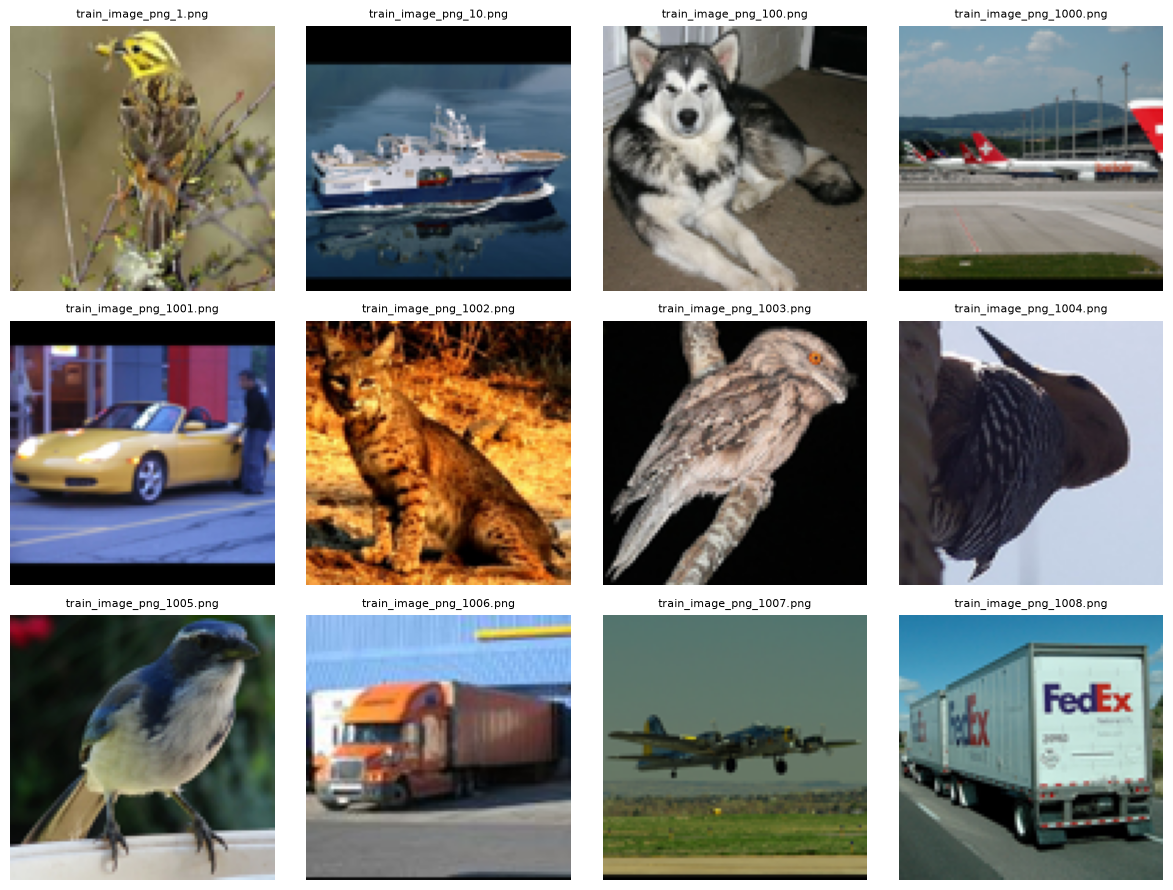

In [239]:
display_sample_images(
    training_image_paths,
    number_of_images_to_display=12
)

In [240]:
print("=" * 60)
print("PHASE 2 — DATASET EXPLORATION SUMMARY")
print("=" * 60)

print(f"Total Images              : {len(all_image_paths)}")
print(
    f"Unique Image Dimensions   : "
    f"{unique_image_dimensions}"
)
print(
    f"Color Modes               : "
    f"{unique_image_color_modes}"
)
print(
    f"Image Formats             : "
    f"{image_format_counts}"
)
print(f"Valid Images              : {valid_image_count}")
print(f"Corrupted Images          : {corrupted_image_count}")

PHASE 2 — DATASET EXPLORATION SUMMARY
Total Images              : 113000
Unique Image Dimensions   : [(96, 96)]
Color Modes               : {'RGB': 113000}
Image Formats             : {'PNG': 113000}
Valid Images              : 113000
Corrupted Images          : 0


## Phase 2 — Conclusion

The STL-10 dataset was successfully explored and validated. The dataset contains **113,000 images**, consisting of **5,000 training images, 8,000 testing images, and 100,000 unlabeled images**.

The image inspection showed that all images have a consistent size of **96 × 96 pixels**, use the **RGB** color mode, and are stored in **PNG** format. Only one unique image dimension, `(96, 96)`, was found across the dataset.

The validation process also confirmed that all **113,000 images are valid**, with **0 corrupted images** detected. This confirms that the dataset is structurally consistent and suitable for the next stages of the project.

Sample images were also visualized to inspect the dataset qualitatively. No mathematical transformation has been performed during this phase. The purpose of Phase 2 was only to understand, inspect, and validate the dataset.

The results from this phase provide a reliable foundation for **Phase 3 — Image Preprocessing**, where the images will be loaded into NumPy arrays and their pixel values will be prepared for the mathematical processing used later in the Diffusion Maps algorithm.


# PHASE 3 — IMAGE PREPROCESSING

## Libraries for Image Preprocessing

This phase uses Pillow to load the PNG images and NumPy to convert the
pixel values into numerical arrays.

NumPy is used for the numerical processing because the later Diffusion Maps
algorithm will perform matrix and vector calculations using NumPy.

No distance, similarity, graph, eigenvalue, or clustering calculations
are performed in this phase.

In [241]:
from typing import Tuple
import numpy as np

### Load an Image

The first step is to load an image from its file path.

The image is explicitly converted to RGB so that every image has exactly
three color channels.

The expected shape is:

    Height × Width × Channels
    = 96 × 96 × 3

The returned NumPy array initially contains unsigned 8-bit integers
(`uint8`), where each pixel value normally lies between 0 and 255.

In [242]:
def load_image_as_numpy_array(
    image_path: Path
) -> np.ndarray:
    """
    Load an image and convert it into an RGB NumPy array.

    Parameters
    ----------
    image_path : Path
        Path to the image file.

    Returns
    -------
    np.ndarray
        RGB image represented as a NumPy array.

    Notes
    -----
    The expected image shape is:

        (height, width, channels)

    For STL-10:

        (96, 96, 3)
    """

    with Image.open(image_path) as image:

        rgb_image: Image.Image = image.convert("RGB")

        image_array: np.ndarray = np.asarray(
            rgb_image
        )

    return image_array

In [243]:
sample_image_path: Path = training_image_paths[0]

sample_image_array: np.ndarray = (
    load_image_as_numpy_array(
        sample_image_path
    )
)

print("=" * 60)
print("LOADED IMAGE INFORMATION")
print("=" * 60)

print(f"Filename  : {sample_image_path.name}")
print(f"Shape     : {sample_image_array.shape}")
print(f"Data Type : {sample_image_array.dtype}")
print(
    f"Minimum Pixel Value : "
    f"{sample_image_array.min()}"
)
print(
    f"Maximum Pixel Value : "
    f"{sample_image_array.max()}"
)

LOADED IMAGE INFORMATION
Filename  : train_image_png_1.png
Shape     : (96, 96, 3)
Data Type : uint8
Minimum Pixel Value : 0
Maximum Pixel Value : 255


### Convert Pixel Data to Floating Point

The original image uses `uint8`, which stores integer pixel values.

Before normalization, we convert the array to `float32`.

This allows the pixel values to contain decimal values after normalization.

The conversion does not change the image dimensions.

In [244]:
def convert_image_array_to_float32(
    image_array: np.ndarray
) -> np.ndarray:
    """
    Convert image pixel values from uint8 to float32.

    Parameters
    ----------
    image_array : np.ndarray
        Image represented as a NumPy array.

    Returns
    -------
    np.ndarray
        Image array represented using float32 values.
    """

    floating_point_image_array: np.ndarray = (
        image_array.astype(np.float32)
    )

    return floating_point_image_array

In [245]:
floating_point_image_array: np.ndarray = (
    convert_image_array_to_float32(
        sample_image_array
    )
)

print("=" * 60)
print("FLOAT32 CONVERSION")
print("=" * 60)

print(
    f"Data Type Before : "
    f"{sample_image_array.dtype}"
)

print(
    f"Data Type After  : "
    f"{floating_point_image_array.dtype}"
)

print(
    f"Shape            : "
    f"{floating_point_image_array.shape}"
)

FLOAT32 CONVERSION
Data Type Before : uint8
Data Type After  : float32
Shape            : (96, 96, 3)


### Pixel Normalization

The original pixel values are represented between 0 and 255.

We normalize each pixel using:

    normalized_pixel = original_pixel / 255

Therefore:

    0 → 0 / 255 = 0
    255 → 255 / 255 = 1

The resulting pixel range is:

    0 ≤ normalized_pixel ≤ 1

This does not change the relative brightness represented by the pixel.
It only changes the numerical scale.

For an RGB pixel:

    [R, G, B]

the normalized pixel becomes:

    [R/255, G/255, B/255]

In [246]:
def normalize_image_pixel_values(
    floating_point_image_array: np.ndarray
) -> np.ndarray:
    """
    Normalize image pixel values from [0, 255] to [0, 1].

    Parameters
    ----------
    floating_point_image_array : np.ndarray
        Image array containing floating-point pixel values.

    Returns
    -------
    np.ndarray
        Image array with pixel values normalized to [0, 1].

    Mathematical Formula
    --------------------
    normalized_pixel = original_pixel / 255

    The value 255 is used because RGB images stored as uint8
    use values from 0 to 255.
    """

    maximum_uint8_pixel_value: float = 255.0

    normalized_image_array: np.ndarray = (
        floating_point_image_array
        / maximum_uint8_pixel_value
    )

    return normalized_image_array

In [247]:
normalized_sample_image_array: np.ndarray = (
    normalize_image_pixel_values(
        floating_point_image_array
    )
)

print("=" * 60)
print("PIXEL NORMALIZATION")
print("=" * 60)

print(
    f"Data Type : "
    f"{normalized_sample_image_array.dtype}"
)

print(
    f"Minimum Value : "
    f"{normalized_sample_image_array.min():.6f}"
)

print(
    f"Maximum Value : "
    f"{normalized_sample_image_array.max():.6f}"
)

print(
    f"Shape : "
    f"{normalized_sample_image_array.shape}"
)

PIXEL NORMALIZATION
Data Type : float32
Minimum Value : 0.000000
Maximum Value : 1.000000
Shape : (96, 96, 3)


In [248]:
original_pixel_value: float = 106.0

normalized_pixel_value: float = (
    original_pixel_value / 255.0
)

print("=" * 60)
print("NORMALIZATION FORMULA VERIFICATION")
print("=" * 60)

print(
    f"Original Pixel Value   : "
    f"{original_pixel_value}"
)

print(
    f"Normalized Pixel Value : "
    f"{normalized_pixel_value:.8f}"
)

print(
    "\nFormula:"
)

print(
    f"{original_pixel_value} / 255 "
    f"= {normalized_pixel_value:.8f}"
)

NORMALIZATION FORMULA VERIFICATION
Original Pixel Value   : 106.0
Normalized Pixel Value : 0.41568627

Formula:
106.0 / 255 = 0.41568627


In [249]:
normalized_values_are_valid: bool = bool(
    np.all(
        (normalized_sample_image_array >= 0.0)
        &
        (normalized_sample_image_array <= 1.0)
    )
)

print("=" * 60)
print("NORMALIZED RANGE VALIDATION")
print("=" * 60)

print(
    "All values between 0 and 1 :",
    normalized_values_are_valid
)

NORMALIZED RANGE VALIDATION
All values between 0 and 1 : True


In [250]:
sample_pixel_position: tuple[int, int] = (0, 0)

original_rgb_pixel: np.ndarray = (
    sample_image_array[
        sample_pixel_position[0],
        sample_pixel_position[1]
    ]
)

normalized_rgb_pixel: np.ndarray = (
    normalized_sample_image_array[
        sample_pixel_position[0],
        sample_pixel_position[1]
    ]
)

print("=" * 60)
print("PIXEL TRANSFORMATION EXAMPLE")
print("=" * 60)

print(
    "Original Pixel   :",
    original_rgb_pixel
)

print(
    "Normalized Pixel :",
    normalized_rgb_pixel
)

PIXEL TRANSFORMATION EXAMPLE
Original Pixel   : [146 143 110]
Normalized Pixel : [0.57254905 0.56078434 0.43137255]


In [251]:
def preprocess_single_image(
    image_path: Path
) -> np.ndarray:
    """
    Load and preprocess one image.

    Processing steps
    ----------------
    1. Load the image.
    2. Convert it to RGB.
    3. Convert pixel values to float32.
    4. Normalize pixel values from [0, 255] to [0, 1].

    Mathematical Formula
    --------------------
    normalized_pixel = original_pixel / 255

    Returns
    -------
    np.ndarray
        Preprocessed image with shape (96, 96, 3)
        and normalized values in the range [0, 1].
    """

    image_array: np.ndarray = (
        load_image_as_numpy_array(image_path)
    )

    floating_point_image_array: np.ndarray = (
        convert_image_array_to_float32(image_array)
    )

    normalized_image_array: np.ndarray = (
        normalize_image_pixel_values(
            floating_point_image_array
        )
    )

    return normalized_image_array

In [252]:
preprocessed_sample_image: np.ndarray = (
    preprocess_single_image(
        sample_image_path
    )
)

print("=" * 60)
print("COMPLETE IMAGE PREPROCESSING")
print("=" * 60)

print(
    f"Shape     : "
    f"{preprocessed_sample_image.shape}"
)

print(
    f"Data Type : "
    f"{preprocessed_sample_image.dtype}"
)

print(
    f"Minimum   : "
    f"{preprocessed_sample_image.min():.6f}"
)

print(
    f"Maximum   : "
    f"{preprocessed_sample_image.max():.6f}"
)

COMPLETE IMAGE PREPROCESSING
Shape     : (96, 96, 3)
Data Type : float32
Minimum   : 0.000000
Maximum   : 1.000000


In [253]:
def display_original_and_preprocessed_image(
    image_path: Path
) -> None:
    """
    Display an original image and its normalized version
    side by side.

    This visualization demonstrates that normalization changes
    the numerical scale of the pixels without changing the
    visual structure of the image.
    """

    original_image_array: np.ndarray = (
        load_image_as_numpy_array(image_path)
    )

    preprocessed_image_array: np.ndarray = (
        preprocess_single_image(image_path)
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(8, 4)
    )

    axes[0].imshow(original_image_array)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(preprocessed_image_array)
    axes[1].set_title("Normalized Image")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

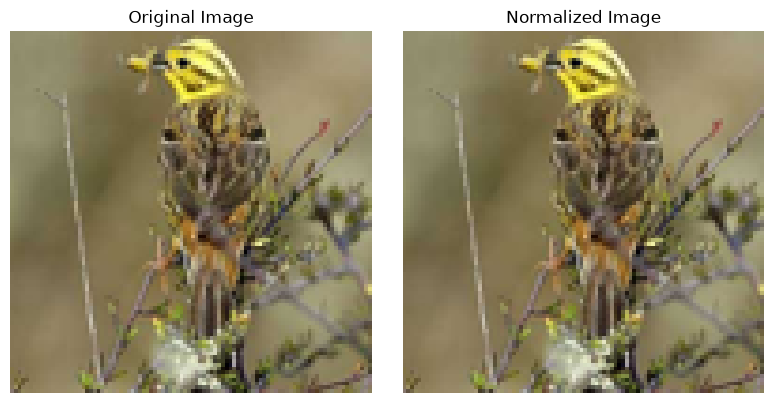

In [254]:
display_original_and_preprocessed_image(
    sample_image_path
)

In [255]:
print("=" * 60)
print("PHASE 3 — IMAGE PREPROCESSING SUMMARY")
print("=" * 60)

print(
    f"Image Shape              : "
    f"{preprocessed_sample_image.shape}"
)

print(
    f"Data Type                : "
    f"{preprocessed_sample_image.dtype}"
)

print(
    f"Minimum Pixel Value      : "
    f"{preprocessed_sample_image.min():.6f}"
)

print(
    f"Maximum Pixel Value      : "
    f"{preprocessed_sample_image.max():.6f}"
)

print(
    f"Values Within [0, 1]     : "
    f"{normalized_values_are_valid}"
)

print(
    f"Resizing Required        : No"
)

PHASE 3 — IMAGE PREPROCESSING SUMMARY
Image Shape              : (96, 96, 3)
Data Type                : float32
Minimum Pixel Value      : 0.000000
Maximum Pixel Value      : 1.000000
Values Within [0, 1]     : True
Resizing Required        : No


## Phase 3 — Conclusion

The image preprocessing stage was successfully completed. The selected STL-10 image was loaded as an RGB NumPy array with a shape of **(96, 96, 3)** and an original data type of `uint8`. The original pixel values were represented in the range **0 to 255**.

The image was then converted from `uint8` to `float32` so that decimal values could be used during numerical processing. Pixel normalization was performed using the formula:

$$
x_{\text{normalized}} = \frac{x_{\text{original}}}{255}
$$

This converted the pixel values from the range **[0, 255]** to **[0, 1]**. For example, the pixel value 106 was converted to approximately **0.41568627**. The validation confirmed that all normalized pixel values were within the required range of **[0, 1]**.

Resizing was not required because Phase 2 confirmed that all STL-10 images already have the same dimensions of **96 × 96 pixels**. Therefore, the original image resolution was preserved.

The preprocessing function successfully produces an image with shape **(96, 96, 3)**, data type `float32`, and normalized pixel values between **0 and 1**. These prepared numerical images provide the foundation for the next phase, where each image will be converted into a mathematical feature vector for constructing the feature matrix.


# PHASE 4 — FEATURE MATRIX

## Selected Image Dataset

For this project, a subset of 500 training images is used for the initial
Diffusion Maps experiment.

Using a subset makes the pairwise mathematical calculations computationally
manageable while still providing enough samples to demonstrate the complete
Diffusion Maps pipeline.

Each selected image has already been validated and preprocessed in the
previous phases.

In [256]:
number_of_selected_images: int = 500

selected_image_paths: List[Path] = (
    training_image_paths[:number_of_selected_images]
)

In [257]:
print("=" * 60)
print("SELECTED IMAGE DATASET")
print("=" * 60)

print(f"Images Selected : {len(selected_image_paths)}")

print(
    f"First Image     : "
    f"{selected_image_paths[0].name}"
)

print(
    f"Last Image      : "
    f"{selected_image_paths[-1].name}"
)

SELECTED IMAGE DATASET
Images Selected : 500
First Image     : train_image_png_1.png
Last Image      : train_image_png_1448.png


### Flattening an Image

The preprocessed image has shape:

$$
96 \times 96 \times 3
$$

The total number of numerical values is:

$$
96 \times 96 \times 3 = 27648
$$

Flattening converts this three-dimensional array into a one-dimensional
feature vector.

The operation does not change the numerical values. It only changes their
shape.

Therefore:

$$
(96,96,3) \rightarrow (27648,)
$$

This feature vector will represent one image in the feature matrix.

In [258]:
def flatten_preprocessed_image(
    preprocessed_image_array: np.ndarray
) -> np.ndarray:
    """
    Convert a preprocessed image into a one-dimensional feature vector.

    Parameters
    ----------
    preprocessed_image_array : np.ndarray
        Preprocessed image with shape (96, 96, 3).

    Returns
    -------
    np.ndarray
        One-dimensional feature vector with 27,648 values.

    Mathematical Explanation
    ------------------------
    The image contains:

        96 × 96 × 3 = 27,648

    numerical pixel values.

    Flattening changes the shape:

        (96, 96, 3) → (27,648,)

    The pixel values themselves are not changed.
    """

    feature_vector: np.ndarray = (
        preprocessed_image_array.flatten()
    )

    return feature_vector

In [259]:
sample_feature_vector: np.ndarray = (
    flatten_preprocessed_image(
        preprocessed_sample_image
    )
)

print("=" * 60)
print("FEATURE VECTOR INFORMATION")
print("=" * 60)

print(
    f"Original Image Shape : "
    f"{preprocessed_sample_image.shape}"
)

print(
    f"Feature Vector Shape : "
    f"{sample_feature_vector.shape}"
)

print(
    f"Feature Vector Length : "
    f"{len(sample_feature_vector)}"
)

print(
    f"Data Type : "
    f"{sample_feature_vector.dtype}"
)

print(
    "\nFirst 10 Feature Values:"
)

print(
    sample_feature_vector[:10]
)

FEATURE VECTOR INFORMATION
Original Image Shape : (96, 96, 3)
Feature Vector Shape : (27648,)
Feature Vector Length : 27648
Data Type : float32

First 10 Feature Values:
[0.57254905 0.56078434 0.43137255 0.57254905 0.56078434 0.43137255
 0.57254905 0.56078434 0.43137255 0.57254905]


In [260]:
image_height: int = 96
image_width: int = 96
number_of_color_channels: int = 3

expected_feature_count: int = (
    image_height
    * image_width
    * number_of_color_channels
)

actual_feature_count: int = (
    len(sample_feature_vector)
)

print("=" * 60)
print("FEATURE COUNT VERIFICATION")
print("=" * 60)

print(
    f"Expected Feature Count : "
    f"{expected_feature_count}"
)

print(
    f"Actual Feature Count   : "
    f"{actual_feature_count}"
)

print(
    f"Feature Count Correct  : "
    f"{expected_feature_count == actual_feature_count}"
)

FEATURE COUNT VERIFICATION
Expected Feature Count : 27648
Actual Feature Count   : 27648
Feature Count Correct  : True


In [261]:
def create_image_feature_matrix(
    image_paths: List[Path]
) -> np.ndarray:
    """
    Create a feature matrix from a collection of images.

    Parameters
    ----------
    image_paths : List[Path]
        List containing paths to the selected images.

    Returns
    -------
    np.ndarray
        Feature matrix where:

        rows    = images
        columns = pixel features

    Mathematical Structure
    ----------------------
    For 500 images:

        X ∈ R^(500 * 27648)

    Each row contains the flattened normalized pixel values
    of one image.
    """

    image_feature_vectors: List[np.ndarray] = []

    for image_path in image_paths:

        preprocessed_image: np.ndarray = (
            preprocess_single_image(
                image_path
            )
        )

        image_feature_vector: np.ndarray = (
            flatten_preprocessed_image(
                preprocessed_image
            )
        )

        image_feature_vectors.append(
            image_feature_vector
        )

    image_feature_matrix: np.ndarray = (
        np.vstack(image_feature_vectors)
    )

    return image_feature_matrix

In [262]:
image_feature_matrix: np.ndarray = (
    create_image_feature_matrix(
        selected_image_paths
    )
)

print("=" * 60)
print("FEATURE MATRIX")
print("=" * 60)

print(
    f"Shape      : "
    f"{image_feature_matrix.shape}"
)

print(
    f"Data Type  : "
    f"{image_feature_matrix.dtype}"
)

print(
    f"Min Value  : "
    f"{image_feature_matrix.min():.4f}"
)

print(
    f"Max Value  : "
    f"{image_feature_matrix.max():.4f}"
)

FEATURE MATRIX
Shape      : (500, 27648)
Data Type  : float32
Min Value  : 0.0000
Max Value  : 1.0000


In [263]:
feature_matrix_values_are_valid: bool = bool(
    np.all(
        (image_feature_matrix >= 0.0)
        &
        (image_feature_matrix <= 1.0)
    )
)

print("=" * 60)
print("FEATURE MATRIX RANGE VALIDATION")
print("=" * 60)

print(
    "All values between 0 and 1 :",
    feature_matrix_values_are_valid
)

FEATURE MATRIX RANGE VALIDATION
All values between 0 and 1 : True


In [264]:
expected_number_of_images: int = (
    len(selected_image_paths)
)

expected_number_of_features: int = (
    96 * 96 * 3
)

expected_feature_matrix_shape: tuple[int, int] = (
    expected_number_of_images,
    expected_number_of_features
)

actual_feature_matrix_shape: tuple[int, int] = (
    image_feature_matrix.shape
)

print("=" * 60)
print("FEATURE MATRIX SHAPE VALIDATION")
print("=" * 60)

print(
    f"Expected Shape : "
    f"{expected_feature_matrix_shape}"
)

print(
    f"Actual Shape   : "
    f"{actual_feature_matrix_shape}"
)

print(
    f"Shape Correct  : "
    f"{expected_feature_matrix_shape == actual_feature_matrix_shape}"
)

FEATURE MATRIX SHAPE VALIDATION
Expected Shape : (500, 27648)
Actual Shape   : (500, 27648)
Shape Correct  : True


In [265]:
first_image_feature_vector: np.ndarray = (
    image_feature_matrix[0]
)

second_image_feature_vector: np.ndarray = (
    image_feature_matrix[1]
)

print("=" * 60)
print("FEATURE MATRIX ROW VERIFICATION")
print("=" * 60)

print(
    f"First Image Feature Count  : "
    f"{len(first_image_feature_vector)}"
)

print(
    f"Second Image Feature Count : "
    f"{len(second_image_feature_vector)}"
)

print(
    f"Number of Matrix Rows      : "
    f"{image_feature_matrix.shape[0]}"
)

FEATURE MATRIX ROW VERIFICATION
First Image Feature Count  : 27648
Second Image Feature Count : 27648
Number of Matrix Rows      : 500


In [266]:
print("=" * 60)
print("PHASE 4 — FEATURE MATRIX SUMMARY")
print("=" * 60)

print(
    f"Images Represented       : "
    f"{image_feature_matrix.shape[0]}"
)

print(
    f"Features Per Image       : "
    f"{image_feature_matrix.shape[1]}"
)

print(
    f"Feature Matrix Shape     : "
    f"{image_feature_matrix.shape}"
)

print(
    f"Data Type               : "
    f"{image_feature_matrix.dtype}"
)

print(
    f"Minimum Feature Value   : "
    f"{image_feature_matrix.min():.4f}"
)

print(
    f"Maximum Feature Value   : "
    f"{image_feature_matrix.max():.4f}"
)

print(
    f"Values Within [0, 1]    : "
    f"{feature_matrix_values_are_valid}"
)

print(
    f"Shape Correct            : "
    f"{expected_feature_matrix_shape == actual_feature_matrix_shape}"
)

PHASE 4 — FEATURE MATRIX SUMMARY
Images Represented       : 500
Features Per Image       : 27648
Feature Matrix Shape     : (500, 27648)
Data Type               : float32
Minimum Feature Value   : 0.0000
Maximum Feature Value   : 1.0000
Values Within [0, 1]    : True
Shape Correct            : True


## Phase 4 — Conclusion

The feature matrix construction stage was successfully completed using a selected subset of **500 training images** from the STL-10 dataset. Each preprocessed image had an original shape of **96 × 96 × 3**, which contains:

$$
96 \times 96 \times 3 = 27,648
$$

numerical pixel values.

Each image was therefore converted into a one-dimensional feature vector with **27,648 features**. The feature vector verification confirmed that the expected and actual feature counts were both 27,648.

The individual feature vectors were then combined to create the feature matrix. The resulting matrix has a shape of **(500, 27,648)**, where each row represents one image and each column represents a pixel feature.

The feature matrix uses the `float32` data type, with feature values ranging from **0.0000 to 1.0000**. The range validation confirmed that all feature values are within the expected **[0, 1]** range. The matrix shape was also successfully verified as **(500, 27,648)**.

Therefore, the image dataset has now been converted from visual image data into a consistent numerical representation. This feature matrix will serve as the input for **Phase 5 — Distance Calculation**, where the similarity or dissimilarity between pairs of images will be mathematically measured.


# PHASE 5 — DISTANCE CALCULATION


Euclidean distance measures the straight-line distance between two points
in a multidimensional space.

In this project, each image is represented by a 27,648-dimensional feature
vector.

The Euclidean distance between two image feature vectors is:

$$
d(X_i,X_j)
=
\sqrt{
\sum_{k=1}^{27648}
(x_{ik}-x_{jk})^2
}
$$

The calculation is implemented using NumPy.

A smaller distance indicates that two images have more similar numerical
feature values, while a larger distance indicates greater numerical
difference.

In [267]:
def calculate_euclidean_distance(
    first_feature_vector: np.ndarray,
    second_feature_vector: np.ndarray
) -> float:
    """
    Calculate the Euclidean distance between two feature vectors.

    Parameters
    ----------
    first_feature_vector : np.ndarray
        Feature vector representing the first image.

    second_feature_vector : np.ndarray
        Feature vector representing the second image.

    Returns
    -------
    float
        Euclidean distance between the two feature vectors.

    Mathematical Formula
    --------------------
    The Euclidean distance is:

    d(X, Y) =
        sqrt(
            sum((X_k - Y_k)^2)
        )

    where each k represents one image feature.

    For this project, each image contains 27,648 features.
    """

    feature_difference: np.ndarray = (
        first_feature_vector
        - second_feature_vector
    )

    squared_feature_difference: np.ndarray = (
        feature_difference ** 2
    )

    sum_of_squared_differences: np.float32 = (
        np.sum(squared_feature_difference)
    )

    euclidean_distance: float = float(
        np.sqrt(sum_of_squared_differences)
    )

    return euclidean_distance

In [268]:
first_feature_vector: np.ndarray = (
    image_feature_matrix[0]
)

second_feature_vector: np.ndarray = (
    image_feature_matrix[1]
)

first_two_image_distance: float = (
    calculate_euclidean_distance(
        first_feature_vector,
        second_feature_vector
    )
)

print("=" * 60)
print("EUCLIDEAN DISTANCE")
print("=" * 60)

print(
    f"Distance Between Image 1 and Image 2 : "
    f"{first_two_image_distance:.6f}"
)

EUCLIDEAN DISTANCE
Distance Between Image 1 and Image 2 : 56.508324


In [269]:
manual_feature_difference: np.ndarray = (
    first_feature_vector
    - second_feature_vector
)

manual_squared_difference: np.ndarray = (
    manual_feature_difference ** 2
)

manual_sum_of_squared_differences: float = float(
    np.sum(manual_squared_difference)
)

manual_euclidean_distance: float = float(
    np.sqrt(
        manual_sum_of_squared_differences
    )
)

print("=" * 60)
print("EUCLIDEAN DISTANCE VERIFICATION")
print("=" * 60)

print(
    f"Function Result : "
    f"{first_two_image_distance:.6f}"
)

print(
    f"Manual Result   : "
    f"{manual_euclidean_distance:.6f}"
)

print(
    f"Results Match   : "
    f"{np.isclose(first_two_image_distance, manual_euclidean_distance)}"
)

EUCLIDEAN DISTANCE VERIFICATION
Function Result : 56.508324
Manual Result   : 56.508322
Results Match   : True


In [270]:
same_image_distance: float = (
    calculate_euclidean_distance(
        first_feature_vector,
        first_feature_vector
    )
)

print("=" * 60)
print("SELF-DISTANCE TEST")
print("=" * 60)

print(
    f"Distance of Image 1 from Itself : "
    f"{same_image_distance:.6f}"
)

print(
    f"Distance is Zero : "
    f"{np.isclose(same_image_distance, 0.0)}"
)

SELF-DISTANCE TEST
Distance of Image 1 from Itself : 0.000000
Distance is Zero : True


In [271]:
distance_image_one_to_two: float = (
    calculate_euclidean_distance(
        image_feature_matrix[0],
        image_feature_matrix[1]
    )
)

distance_image_two_to_one: float = (
    calculate_euclidean_distance(
        image_feature_matrix[1],
        image_feature_matrix[0]
    )
)

print("=" * 60)
print("DISTANCE SYMMETRY TEST")
print("=" * 60)

print(
    f"d(Image 1, Image 2) : "
    f"{distance_image_one_to_two:.6f}"
)

print(
    f"d(Image 2, Image 1) : "
    f"{distance_image_two_to_one:.6f}"
)

print(
    f"Symmetric : "
    f"{np.isclose(
        distance_image_one_to_two,
        distance_image_two_to_one
    )}"
)

DISTANCE SYMMETRY TEST
d(Image 1, Image 2) : 56.508324
d(Image 2, Image 1) : 56.508324
Symmetric : True


### Distance Matrix

The distance matrix stores the Euclidean distance between every pair of
selected images.

For 500 images, the matrix has the shape:

$$
D \in \mathbb{R}^{500 \times 500}
$$

Each element is:

$$
D_{ij}=d(X_i,X_j)
$$

where $X_i$ and $X_j$ are the feature vectors of images $i$ and $j$.

Because Euclidean distance is symmetric:

$$
D_{ij}=D_{ji}
$$

and because an image has zero distance from itself:

$$
D_{ii}=0
$$

The matrix is calculated using NumPy only for the mathematical operations.

In [272]:
def calculate_euclidean_distance_matrix(
    image_feature_matrix: np.ndarray
) -> np.ndarray:
    """
    Calculate the Euclidean distance between every pair of images.

    Parameters
    ----------
    image_feature_matrix : np.ndarray
        Matrix where each row represents one image.

    Returns
    -------
    np.ndarray
        Symmetric Euclidean distance matrix.

    Mathematical Formula
    --------------------
    For two images X_i and X_j:

    D_ij =
        sqrt(
            sum(
                (X_i,k - X_j,k)^2
            )
        )

    where k represents each feature.

    For N images, the resulting matrix has shape:

        (N, N)
    """

    number_of_images: int = (
        image_feature_matrix.shape[0]
    )

    euclidean_distance_matrix: np.ndarray = (
        np.zeros(
            (
                number_of_images,
                number_of_images
            ),
            dtype=np.float32
        )
    )

    for first_image_index in range(
        number_of_images
    ):

        for second_image_index in range(
            first_image_index + 1,
            number_of_images
        ):

            image_distance: float = (
                calculate_euclidean_distance(
                    image_feature_matrix[
                        first_image_index
                    ],
                    image_feature_matrix[
                        second_image_index
                    ]
                )
            )

            euclidean_distance_matrix[
                first_image_index,
                second_image_index
            ] = image_distance

            euclidean_distance_matrix[
                second_image_index,
                first_image_index
            ] = image_distance

    return euclidean_distance_matrix

In [273]:
euclidean_distance_matrix: np.ndarray = (
    calculate_euclidean_distance_matrix(
        image_feature_matrix
    )
)

print("=" * 60)
print("DISTANCE MATRIX")
print("=" * 60)

print(
    f"Shape : "
    f"{euclidean_distance_matrix.shape}"
)

print(
    f"Type  : "
    f"{euclidean_distance_matrix.dtype}"
)

DISTANCE MATRIX
Shape : (500, 500)
Type  : float32


In [274]:
print("=" * 60)
print("FIRST 5 × 5 DISTANCE MATRIX")
print("=" * 60)

print(
    euclidean_distance_matrix[:5, :5]
)

FIRST 5 × 5 DISTANCE MATRIX
[[ 0.       56.508324 47.534904 42.364418 55.397068]
 [56.508324  0.       61.14502  60.73753  47.32358 ]
 [47.534904 61.14502   0.       54.955616 60.176376]
 [42.364418 60.73753  54.955616  0.       59.093998]
 [55.397068 47.32358  60.176376 59.093998  0.      ]]


In [275]:
distance_matrix_diagonal_is_zero: bool = bool(
    np.allclose(
        np.diag(euclidean_distance_matrix),
        0.0
    )
)

print("=" * 60)
print("DISTANCE MATRIX DIAGONAL TEST")
print("=" * 60)

print(
    f"Diagonal all zero : "
    f"{distance_matrix_diagonal_is_zero}"
)

DISTANCE MATRIX DIAGONAL TEST
Diagonal all zero : True


In [276]:
distance_matrix_is_symmetric: bool = bool(
    np.allclose(
        euclidean_distance_matrix,
        euclidean_distance_matrix.T
    )
)

print("=" * 60)
print("DISTANCE MATRIX SYMMETRY TEST")
print("=" * 60)

print(
    f"Matrix symmetric : "
    f"{distance_matrix_is_symmetric}"
)

DISTANCE MATRIX SYMMETRY TEST
Matrix symmetric : True


In [277]:
minimum_euclidean_distance: float = float(
    np.min(euclidean_distance_matrix)
)

maximum_euclidean_distance: float = float(
    np.max(euclidean_distance_matrix)
)

print("=" * 60)
print("DISTANCE RANGE")
print("=" * 60)

print(
    f"Minimum Distance : "
    f"{minimum_euclidean_distance:.6f}"
)

print(
    f"Maximum Distance : "
    f"{maximum_euclidean_distance:.6f}"
)

DISTANCE RANGE
Minimum Distance : 0.000000
Maximum Distance : 135.606415


In [278]:
non_zero_distance_values: np.ndarray = (
    euclidean_distance_matrix[
        euclidean_distance_matrix > 0
    ]
)

minimum_non_zero_euclidean_distance: float = float(
    np.min(non_zero_distance_values)
)

print("=" * 60)
print("NON-ZERO DISTANCE")
print("=" * 60)

print(
    f"Minimum Non-Zero Distance : "
    f"{minimum_non_zero_euclidean_distance:.6f}"
)

NON-ZERO DISTANCE
Minimum Non-Zero Distance : 21.962809


In [279]:
print("=" * 60)
print("PHASE 5 — DISTANCE CALCULATION SUMMARY")
print("=" * 60)

print(
    f"Number of Images        : "
    f"{image_feature_matrix.shape[0]}"
)

print(
    f"Features Per Image      : "
    f"{image_feature_matrix.shape[1]}"
)

print(
    f"Distance Matrix Shape   : "
    f"{euclidean_distance_matrix.shape}"
)

print(
    f"Data Type              : "
    f"{euclidean_distance_matrix.dtype}"
)

print(
    f"Diagonal All Zero      : "
    f"{distance_matrix_diagonal_is_zero}"
)

print(
    f"Matrix Symmetric       : "
    f"{distance_matrix_is_symmetric}"
)

print(
    f"Minimum Distance       : "
    f"{minimum_euclidean_distance:.6f}"
)

print(
    f"Minimum Non-Zero       : "
    f"{minimum_non_zero_euclidean_distance:.6f}"
)

print(
    f"Maximum Distance       : "
    f"{maximum_euclidean_distance:.6f}"
)

PHASE 5 — DISTANCE CALCULATION SUMMARY
Number of Images        : 500
Features Per Image      : 27648
Distance Matrix Shape   : (500, 500)
Data Type              : float32
Diagonal All Zero      : True
Matrix Symmetric       : True
Minimum Distance       : 0.000000
Minimum Non-Zero       : 21.962809
Maximum Distance       : 135.606415


## Phase 5 — Conclusion

The distance calculation stage was successfully completed for the 500 selected STL-10 images. Each image was represented by a 27,648-dimensional feature vector, and the Euclidean distance was calculated between pairs of images.

The Euclidean distance implementation was verified by comparing the function result with a direct NumPy calculation. The two results were effectively identical, with a small difference caused by floating-point precision:

$$
56.508324 \approx 56.508322
$$

The self-distance test also passed. The distance between an image and itself was:

$$
d(X_i,X_i)=0
$$

The distance matrix was successfully constructed with a shape of **(500, 500)**. This means that the matrix contains the distance between every pair of the 500 selected images.

The matrix was confirmed to be symmetric, satisfying:

$$
D_{ij}=D_{ji}
$$

The diagonal values were also confirmed to be zero, which is an expected property of Euclidean distance.

The calculated distances ranged from **0.000000** to **135.606415**, while the smallest non-zero distance between two different images was **21.962809**.

Therefore, Phase 5 successfully converted the feature matrix into a pairwise distance matrix. This matrix provides the numerical measure of how close or different the images are and will be used in the next phase to construct a similarity relationship between the images.


# PHASE 6 — SIMILARITY MATRIX

## Similarity Scale Parameter

To convert Euclidean distances into similarities, a scale parameter
$\sigma$ is required.

We calculate $\sigma$ using the median of all non-zero pairwise distances:

$$
\sigma =
\operatorname{median}
\left(
D_{ij}:D_{ij}>0
\right)
$$

The zero distances are excluded because they represent an image compared
with itself.

This gives the Gaussian similarity function an appropriate scale based on
the distances in our dataset.

In [280]:
def calculate_similarity_scale_parameter(
    euclidean_distance_matrix: np.ndarray
) -> float:
    """
    Calculate the similarity scale parameter sigma.

    Parameters
    ----------
    euclidean_distance_matrix : np.ndarray
        Pairwise Euclidean distance matrix.

    Returns
    -------
    float
        Median of all non-zero pairwise distances.

    Mathematical Explanation
    ------------------------
    The diagonal of the distance matrix contains zeros because:

        d(X_i, X_i) = 0

    These values are excluded.

    The scale parameter is:

        sigma = median(D_ij : D_ij > 0)

    This provides a simple estimate of the typical distance
    between different images.
    """

    non_zero_distances: np.ndarray = (
        euclidean_distance_matrix[
            euclidean_distance_matrix > 0
        ]
    )

    similarity_scale_parameter: float = float(
        np.median(non_zero_distances)
    )

    return similarity_scale_parameter

In [281]:
similarity_scale_parameter: float = (
    calculate_similarity_scale_parameter(
        euclidean_distance_matrix
    )
)

print("=" * 60)
print("SIMILARITY SCALE PARAMETER")
print("=" * 60)

print(
    f"Sigma (σ) : "
    f"{similarity_scale_parameter:.6f}"
)

SIMILARITY SCALE PARAMETER
Sigma (σ) : 59.973091


In [282]:
def calculate_gaussian_similarity(
    distance_value: float,
    similarity_scale_parameter: float
) -> float:
    """
    Convert one Euclidean distance into a Gaussian similarity.

    Parameters
    ----------
    distance_value : float
        Euclidean distance between two images.

    similarity_scale_parameter : float
        Sigma (σ), which controls the similarity scale.

    Returns
    -------
    float
        Gaussian similarity value.

    Mathematical Formula
    --------------------
    The Gaussian similarity is:

        W_ij =
            exp(
                -(D_ij^2)
                /
                (2 * sigma^2)
            )

    A distance of zero produces similarity 1.

    Increasing distance produces decreasing similarity.
    """

    squared_distance: float = (
        distance_value ** 2
    )

    denominator: float = (
        2.0
        * similarity_scale_parameter ** 2
    )

    exponential_argument: float = (
        -squared_distance
        / denominator
    )

    gaussian_similarity: float = float(
        np.exp(exponential_argument)
    )

    return gaussian_similarity

In [283]:
image_one_image_two_similarity: float = (
    calculate_gaussian_similarity(
        distance_value=first_two_image_distance,
        similarity_scale_parameter=similarity_scale_parameter
    )
)

print("=" * 60)
print("GAUSSIAN SIMILARITY TEST")
print("=" * 60)

print(
    f"Distance : "
    f"{first_two_image_distance:.6f}"
)

print(
    f"Sigma    : "
    f"{similarity_scale_parameter:.6f}"
)

print(
    f"Similarity : "
    f"{image_one_image_two_similarity:.6f}"
)

GAUSSIAN SIMILARITY TEST
Distance : 56.508324
Sigma    : 59.973091
Similarity : 0.641532


In [284]:
self_similarity: float = (
    calculate_gaussian_similarity(
        distance_value=0.0,
        similarity_scale_parameter=similarity_scale_parameter
    )
)

print("=" * 60)
print("SELF-SIMILARITY TEST")
print("=" * 60)

print(
    f"Distance : 0.000000"
)

print(
    f"Similarity : "
    f"{self_similarity:.6f}"
)

print(
    f"Similarity is 1 : "
    f"{np.isclose(self_similarity, 1.0)}"
)

SELF-SIMILARITY TEST
Distance : 0.000000
Similarity : 1.000000
Similarity is 1 : True


In [285]:
def create_gaussian_similarity_matrix(
    euclidean_distance_matrix: np.ndarray,
    similarity_scale_parameter: float
) -> np.ndarray:
    """
    Convert the complete distance matrix into a Gaussian
    similarity matrix.

    Parameters
    ----------
    euclidean_distance_matrix : np.ndarray
        Pairwise Euclidean distance matrix.

    similarity_scale_parameter : float
        Sigma (σ) used by the Gaussian kernel.

    Returns
    -------
    np.ndarray
        Gaussian similarity matrix.

    Mathematical Formula
    --------------------
    Every matrix element is calculated as:

        W_ij =
            exp(
                -(D_ij^2)
                /
                (2 * sigma^2)
            )

    Therefore:

        small distance → high similarity
        large distance  → low similarity

    Since D is symmetric, W is also symmetric.
    """

    squared_distance_matrix: np.ndarray = (
        euclidean_distance_matrix ** 2
    )

    denominator: float = (
        2.0
        * similarity_scale_parameter ** 2
    )

    gaussian_similarity_matrix: np.ndarray = (
        np.exp(
            -squared_distance_matrix
            / denominator
        )
    )

    return gaussian_similarity_matrix.astype(
        np.float32
    )

In [286]:
gaussian_similarity_matrix: np.ndarray = (
    create_gaussian_similarity_matrix(
        euclidean_distance_matrix,
        similarity_scale_parameter
    )
)

print("=" * 60)
print("SIMILARITY MATRIX")
print("=" * 60)

print(
    f"Shape : "
    f"{gaussian_similarity_matrix.shape}"
)

print(
    f"Type  : "
    f"{gaussian_similarity_matrix.dtype}"
)

SIMILARITY MATRIX
Shape : (500, 500)
Type  : float32


In [287]:
print("=" * 60)
print("FIRST 5 × 5 SIMILARITY MATRIX")
print("=" * 60)

print(
    gaussian_similarity_matrix[:5, :5]
)

FIRST 5 × 5 SIMILARITY MATRIX
[[1.         0.6415317  0.7304383  0.77919513 0.6527183 ]
 [0.6415317  1.         0.5946801  0.5988     0.7324766 ]
 [0.7304383  0.5946801  1.         0.6571536  0.6044748 ]
 [0.77919513 0.5988     0.6571536  1.         0.61542064]
 [0.6527183  0.7324766  0.6044748  0.61542064 1.        ]]


In [288]:
similarity_values_are_valid: bool = bool(
    np.all(
        (gaussian_similarity_matrix > 0.0)
        &
        (gaussian_similarity_matrix <= 1.0)
    )
)

print("=" * 60)
print("SIMILARITY RANGE VALIDATION")
print("=" * 60)

print(
    f"Minimum Similarity : "
    f"{gaussian_similarity_matrix.min():.6f}"
)

print(
    f"Maximum Similarity : "
    f"{gaussian_similarity_matrix.max():.6f}"
)

print(
    f"All Values in (0, 1] : "
    f"{similarity_values_are_valid}"
)

SIMILARITY RANGE VALIDATION
Minimum Similarity : 0.077589
Maximum Similarity : 1.000000
All Values in (0, 1] : True


In [289]:
similarity_matrix_diagonal_is_one: bool = bool(
    np.allclose(
        np.diag(gaussian_similarity_matrix),
        1.0
    )
)

print("=" * 60)
print("SIMILARITY MATRIX DIAGONAL TEST")
print("=" * 60)

print(
    f"Diagonal all one : "
    f"{similarity_matrix_diagonal_is_one}"
)

SIMILARITY MATRIX DIAGONAL TEST
Diagonal all one : True


In [290]:
similarity_matrix_is_symmetric: bool = bool(
    np.allclose(
        gaussian_similarity_matrix,
        gaussian_similarity_matrix.T
    )
)

print("=" * 60)
print("SIMILARITY MATRIX SYMMETRY TEST")
print("=" * 60)

print(
    f"Matrix symmetric : "
    f"{similarity_matrix_is_symmetric}"
)

SIMILARITY MATRIX SYMMETRY TEST
Matrix symmetric : True


In [291]:
small_test_distance: float = 20.0
large_test_distance: float = 100.0

small_distance_similarity: float = (
    calculate_gaussian_similarity(
        small_test_distance,
        similarity_scale_parameter
    )
)

large_distance_similarity: float = (
    calculate_gaussian_similarity(
        large_test_distance,
        similarity_scale_parameter
    )
)

print("=" * 60)
print("DISTANCE VS SIMILARITY TEST")
print("=" * 60)

print(
    f"Small Distance : "
    f"{small_test_distance:.2f}"
)

print(
    f"Similarity     : "
    f"{small_distance_similarity:.6f}"
)

print()

print(
    f"Large Distance : "
    f"{large_test_distance:.2f}"
)

print(
    f"Similarity     : "
    f"{large_distance_similarity:.6f}"
)

print()

print(
    "Smaller distance has higher similarity :",
    small_distance_similarity
    > large_distance_similarity
)

DISTANCE VS SIMILARITY TEST
Small Distance : 20.00
Similarity     : 0.945912

Large Distance : 100.00
Similarity     : 0.249042

Smaller distance has higher similarity : True


In [292]:
print("=" * 60)
print("PHASE 6 — SIMILARITY MATRIX SUMMARY")
print("=" * 60)

print(
    f"Number of Images          : "
    f"{gaussian_similarity_matrix.shape[0]}"
)

print(
    f"Similarity Matrix Shape   : "
    f"{gaussian_similarity_matrix.shape}"
)

print(
    f"Data Type                : "
    f"{gaussian_similarity_matrix.dtype}"
)

print(
    f"Sigma (σ)                : "
    f"{similarity_scale_parameter:.6f}"
)

print(
    f"Minimum Similarity       : "
    f"{gaussian_similarity_matrix.min():.6f}"
)

print(
    f"Maximum Similarity       : "
    f"{gaussian_similarity_matrix.max():.6f}"
)

print(
    f"Diagonal All One         : "
    f"{similarity_matrix_diagonal_is_one}"
)

print(
    f"Matrix Symmetric         : "
    f"{similarity_matrix_is_symmetric}"
)

print(
    f"Values Valid             : "
    f"{similarity_values_are_valid}"
)

PHASE 6 — SIMILARITY MATRIX SUMMARY
Number of Images          : 500
Similarity Matrix Shape   : (500, 500)
Data Type                : float32
Sigma (σ)                : 59.973091
Minimum Similarity       : 0.077589
Maximum Similarity       : 1.000000
Diagonal All One         : True
Matrix Symmetric         : True
Values Valid             : True


## Phase 6 — Conclusion

The similarity matrix was successfully constructed from the Euclidean distance matrix of the 500 selected images. A Gaussian kernel was used to convert distances into similarity values according to:

$$
W_{ij}
======

\exp
\left(
-\frac{D_{ij}^{2}}
{2\sigma^{2}}
\right)
$$

The similarity scale parameter was calculated as:

$$
\sigma = 59.973091
$$

The resulting similarity matrix has a shape of **(500, 500)** and uses the `float32` data type.

The Gaussian similarity calculation was verified using the distance between Image 1 and Image 2. Their Euclidean distance was **56.508324**, which produced a similarity value of **0.641532**. The self-similarity test also passed, with an image having a similarity of **1.000000** with itself.

The similarity values ranged from **0.077589** to **1.000000**. This confirms that the Gaussian kernel successfully converted the distance values into values within the expected range. The test using distances of 20 and 100 also confirmed the expected relationship: the smaller distance produced a higher similarity (**0.945912**) while the larger distance produced a lower similarity (**0.249042**).

The similarity matrix was also confirmed to be symmetric, and all diagonal values were equal to one. Therefore, the matrix correctly represents the pairwise similarity relationships between the selected images.

At the end of Phase 6, the project has transformed the image data from feature vectors into a mathematical similarity structure. This similarity matrix will be used in the next phase to represent the images as a **weighted graph**, which is an important foundation for the Diffusion Maps algorithm.


# PHASE 7 — WEIGHTED GRAPH CONSTRUCTION

## Weighted Graph Construction

The similarity matrix can be interpreted as the weighted adjacency
matrix of a graph.

Each image represents one node in the graph, and the similarity
between two images represents the weight of the edge connecting them.

The graph is represented mathematically as:

$$
G=(V,E,W)
$$

where:

- $V$ represents the image nodes.
- $E$ represents connections between image pairs.
- $W$ contains the edge weights.

For this project:

$$
W_{ij}
=
\exp
\left(
-\frac{D_{ij}^{2}}
{2\sigma^{2}}
\right)
$$

Therefore, images with greater similarity have stronger graph
connections, while images with lower similarity have weaker
connections.

The similarity matrix is already a weighted adjacency matrix,
so no additional graph library is required.

In [293]:
def construct_weighted_graph(
    gaussian_similarity_matrix: np.ndarray
) -> np.ndarray:
    """
    Construct the weighted graph from the similarity matrix.

    Parameters
    ----------
    gaussian_similarity_matrix : np.ndarray
        Matrix containing the Gaussian similarity between every
        pair of images.

    Returns
    -------
    np.ndarray
        Weighted adjacency matrix representing the graph.

    Mathematical Explanation
    ------------------------
    Each image is represented as a graph node.

    The similarity between image i and image j becomes the
    edge weight:

        W_ij = similarity(i, j)

    Therefore, the similarity matrix itself represents the
    weighted adjacency matrix of the graph.

    For N images:

        W ∈ R^(N × N)
    """

    weighted_adjacency_matrix: np.ndarray = (
        gaussian_similarity_matrix.copy()
    )

    return weighted_adjacency_matrix

In [294]:
weighted_adjacency_matrix: np.ndarray = (
    construct_weighted_graph(
        gaussian_similarity_matrix
    )
)

print("=" * 60)
print("WEIGHTED GRAPH")
print("=" * 60)

print(
    f"Number of Nodes : "
    f"{weighted_adjacency_matrix.shape[0]}"
)

print(
    f"Matrix Shape    : "
    f"{weighted_adjacency_matrix.shape}"
)

print(
    f"Data Type       : "
    f"{weighted_adjacency_matrix.dtype}"
)

WEIGHTED GRAPH
Number of Nodes : 500
Matrix Shape    : (500, 500)
Data Type       : float32


In [295]:
number_of_graph_nodes: int = (
    weighted_adjacency_matrix.shape[0]
)

print("=" * 60)
print("GRAPH NODE COUNT")
print("=" * 60)

print(
    f"Number of Graph Nodes : "
    f"{number_of_graph_nodes}"
)

print(
    f"Expected Nodes        : "
    f"{image_feature_matrix.shape[0]}"
)

print(
    f"Node Count Correct    : "
    f"{number_of_graph_nodes == image_feature_matrix.shape[0]}"
)

GRAPH NODE COUNT
Number of Graph Nodes : 500
Expected Nodes        : 500
Node Count Correct    : True


In [296]:
graph_weights_are_valid: bool = bool(
    np.all(
        (weighted_adjacency_matrix > 0.0)
        &
        (weighted_adjacency_matrix <= 1.0)
    )
)

print("=" * 60)
print("GRAPH WEIGHT VALIDATION")
print("=" * 60)

print(
    f"Minimum Edge Weight : "
    f"{weighted_adjacency_matrix.min():.6f}"
)

print(
    f"Maximum Edge Weight : "
    f"{weighted_adjacency_matrix.max():.6f}"
)

print(
    f"All Weights Valid   : "
    f"{graph_weights_are_valid}"
)

GRAPH WEIGHT VALIDATION
Minimum Edge Weight : 0.077589
Maximum Edge Weight : 1.000000
All Weights Valid   : True


In [297]:
weighted_graph_is_symmetric: bool = bool(
    np.allclose(
        weighted_adjacency_matrix,
        weighted_adjacency_matrix.T
    )
)

print("=" * 60)
print("WEIGHTED GRAPH SYMMETRY")
print("=" * 60)

print(
    f"Graph is Symmetric : "
    f"{weighted_graph_is_symmetric}"
)

WEIGHTED GRAPH SYMMETRY
Graph is Symmetric : True


In [298]:
graph_diagonal_is_one: bool = bool(
    np.allclose(
        np.diag(weighted_adjacency_matrix),
        1.0
    )
)

print("=" * 60)
print("GRAPH SELF-CONNECTION TEST")
print("=" * 60)

print(
    f"Diagonal All One : "
    f"{graph_diagonal_is_one}"
)

GRAPH SELF-CONNECTION TEST
Diagonal All One : True


In [299]:
print("=" * 60)
print("IMAGE 1 GRAPH CONNECTIONS")
print("=" * 60)

print(
    "Weights from Image 1 to the first 10 images:"
)

print(
    weighted_adjacency_matrix[0, :10]
)

IMAGE 1 GRAPH CONNECTIONS
Weights from Image 1 to the first 10 images:
[1.         0.6415317  0.7304383  0.77919513 0.6527183  0.6844693
 0.5718483  0.64832854 0.6745584  0.73510426]


In [300]:
def calculate_weighted_graph_degrees(
    weighted_adjacency_matrix: np.ndarray
) -> np.ndarray:
    """
    Calculate the weighted degree of every graph node.

    Parameters
    ----------
    weighted_adjacency_matrix : np.ndarray
        Weighted adjacency matrix of the image graph.

    Returns
    -------
    np.ndarray
        One weighted degree value for every image.

    Mathematical Formula
    --------------------
    The degree of node i is:

        q_i = sum(W_ij)

    where the sum is taken across all nodes j.

    A larger degree means the image has stronger total
    connections to the other images.
    """

    weighted_graph_degrees: np.ndarray = (
        np.sum(
            weighted_adjacency_matrix,
            axis=1
        )
    )

    return weighted_graph_degrees.astype(
        np.float32
    )

In [301]:
weighted_graph_degrees: np.ndarray = (
    calculate_weighted_graph_degrees(
        weighted_adjacency_matrix
    )
)

print("=" * 60)
print("WEIGHTED GRAPH DEGREES")
print("=" * 60)

print(
    f"Number of Degrees : "
    f"{len(weighted_graph_degrees)}"
)

print(
    f"First 10 Degrees  : "
)

print(
    weighted_graph_degrees[:10]
)

WEIGHTED GRAPH DEGREES
Number of Degrees : 500
First 10 Degrees  : 
[362.05487 292.78592 302.88885 321.7088  287.4184  275.07227 250.23978
 251.25467 277.38162 304.5342 ]


In [302]:
first_image_degree_manual: float = float(
    np.sum(
        weighted_adjacency_matrix[0]
    )
)

first_image_degree_from_array: float = float(
    weighted_graph_degrees[0]
)

print("=" * 60)
print("GRAPH DEGREE VERIFICATION")
print("=" * 60)

print(
    f"Manual Degree : "
    f"{first_image_degree_manual:.6f}"
)

print(
    f"Function Degree : "
    f"{first_image_degree_from_array:.6f}"
)

print(
    f"Results Match : "
    f"{np.isclose(
        first_image_degree_manual,
        first_image_degree_from_array
    )}"
)

GRAPH DEGREE VERIFICATION
Manual Degree : 362.054871
Function Degree : 362.054871
Results Match : True


In [303]:
minimum_weighted_graph_degree: float = float(
    np.min(weighted_graph_degrees)
)

maximum_weighted_graph_degree: float = float(
    np.max(weighted_graph_degrees)
)

mean_weighted_graph_degree: float = float(
    np.mean(weighted_graph_degrees)
)

print("=" * 60)
print("GRAPH DEGREE STATISTICS")
print("=" * 60)

print(
    f"Minimum Degree : "
    f"{minimum_weighted_graph_degree:.6f}"
)

print(
    f"Maximum Degree : "
    f"{maximum_weighted_graph_degree:.6f}"
)

print(
    f"Mean Degree    : "
    f"{mean_weighted_graph_degree:.6f}"
)

GRAPH DEGREE STATISTICS
Minimum Degree : 151.177155
Maximum Degree : 366.057739
Mean Degree    : 299.049683


In [304]:
all_graph_degrees_positive: bool = bool(
    np.all(
        weighted_graph_degrees > 0.0
    )
)

print("=" * 60)
print("GRAPH DEGREE VALIDATION")
print("=" * 60)

print(
    f"All Degrees Positive : "
    f"{all_graph_degrees_positive}"
)

GRAPH DEGREE VALIDATION
All Degrees Positive : True


In [305]:
print("=" * 60)
print("PHASE 7 — WEIGHTED GRAPH SUMMARY")
print("=" * 60)

print(
    f"Number of Graph Nodes       : "
    f"{number_of_graph_nodes}"
)

print(
    f"Weighted Adjacency Shape    : "
    f"{weighted_adjacency_matrix.shape}"
)

print(
    f"Data Type                  : "
    f"{weighted_adjacency_matrix.dtype}"
)

print(
    f"Minimum Edge Weight        : "
    f"{weighted_adjacency_matrix.min():.6f}"
)

print(
    f"Maximum Edge Weight        : "
    f"{weighted_adjacency_matrix.max():.6f}"
)

print(
    f"Graph Symmetric            : "
    f"{weighted_graph_is_symmetric}"
)

print(
    f"Diagonal All One            : "
    f"{graph_diagonal_is_one}"
)

print(
    f"All Edge Weights Valid     : "
    f"{graph_weights_are_valid}"
)

print(
    f"Minimum Node Degree        : "
    f"{minimum_weighted_graph_degree:.6f}"
)

print(
    f"Maximum Node Degree        : "
    f"{maximum_weighted_graph_degree:.6f}"
)

print(
    f"Mean Node Degree           : "
    f"{mean_weighted_graph_degree:.6f}"
)

print(
    f"All Degrees Positive       : "
    f"{all_graph_degrees_positive}"
)

PHASE 7 — WEIGHTED GRAPH SUMMARY
Number of Graph Nodes       : 500
Weighted Adjacency Shape    : (500, 500)
Data Type                  : float32
Minimum Edge Weight        : 0.077589
Maximum Edge Weight        : 1.000000
Graph Symmetric            : True
Diagonal All One            : True
All Edge Weights Valid     : True
Minimum Node Degree        : 151.177155
Maximum Node Degree        : 366.057739
Mean Node Degree           : 299.049683
All Degrees Positive       : True


## Phase 7 — Conclusion

In Phase 7, the similarity matrix was interpreted as a **weighted adjacency matrix** to construct a graph representation of the image dataset. Each of the 500 selected images was treated as a node, while the similarity between two images represented the weight of the connection between them.

The resulting weighted graph contains **500 nodes** and a weighted adjacency matrix with shape **(500, 500)**. The edge weights range from **0.077589 to 1.000000**, confirming that the similarity values from Phase 6 were successfully preserved.

The graph was verified to be symmetric, with:

$$
W_{ij}=W_{ji}
$$

This means the relationship between two images is the same in both directions. The diagonal values were also confirmed to be 1, representing the maximum similarity of an image with itself.

The weighted degree of each image was then calculated using:

$$
q_i=\sum_{j=1}^{N}W_{ij}
$$

The minimum node degree was **151.177155**, the maximum was **366.057739**, and the mean degree was **299.049683**. All node degrees were positive, which confirms that every image has connections to the graph.

The degree calculation was independently verified for the first image. Both the manual calculation and the implemented function produced **362.054871**, confirming that the implementation is correct.

Therefore, Phase 7 successfully converts the image similarity relationships into a mathematical weighted graph. This graph is the foundation for the next step of the Diffusion Maps method. In **Phase 8**, the graph weights and node degrees will be normalized to create a **transition probability matrix**, beginning the actual diffusion/random-walk process.


# PHASE 8 — TRANSITION PROBABILITY MATRIX

In this phase, the weighted graph is converted into a transition
probability matrix.

The weighted graph contains similarity values rather than
probabilities. Therefore, each row is normalized using the weighted
degree of the corresponding image.

The weighted degree of image $i$ is:

$$
q_i = \sum_{j=1}^{N} W_{ij}
$$

The transition probability from image $i$ to image $j$ is:

$$
P_{ij} = \frac{W_{ij}}{q_i}
$$

This normalization makes every row of the transition matrix sum to
one:

$$
\sum_{j=1}^{N}P_{ij}=1
$$

Therefore, each row represents a probability distribution.

The matrix can be interpreted as a random walk on the image graph.
If a random walker is currently at image $i$, $P_{ij}$ represents
the probability of moving to image $j$.

This is an important step in Diffusion Maps because it transforms
the similarity graph into a Markov transition process. The resulting
transition matrix will be used in the following diffusion steps.

In [306]:
def construct_transition_probability_matrix(
    weighted_adjacency_matrix: np.ndarray,
    weighted_graph_degrees: np.ndarray
) -> np.ndarray:
    """
    Construct the transition probability matrix.

    Parameters
    ----------
    weighted_adjacency_matrix : np.ndarray
        Weighted adjacency matrix containing the similarity
        between every pair of images.

    weighted_graph_degrees : np.ndarray
        Weighted degree of every image node.

    Returns
    -------
    np.ndarray
        Transition probability matrix.

    Mathematical Formula
    --------------------
    The transition probability from image i to image j is:

        P_ij = W_ij / q_i

    where:

        W_ij = weight between image i and image j

        q_i = sum(W_ij)

    Dividing every row by its corresponding degree makes
    the sum of every row equal to one:

        sum(P_ij) = 1

    Therefore, every row becomes a probability distribution.
    """

    transition_probability_matrix: np.ndarray = (
        weighted_adjacency_matrix
        / weighted_graph_degrees[:, np.newaxis]
    )

    return transition_probability_matrix.astype(
        np.float32
    )

In [307]:
transition_probability_matrix: np.ndarray = (
    construct_transition_probability_matrix(
        weighted_adjacency_matrix,
        weighted_graph_degrees
    )
)

print("=" * 60)
print("TRANSITION PROBABILITY MATRIX")
print("=" * 60)

print(
    f"Shape     : "
    f"{transition_probability_matrix.shape}"
)

print(
    f"Data Type : "
    f"{transition_probability_matrix.dtype}"
)

TRANSITION PROBABILITY MATRIX
Shape     : (500, 500)
Data Type : float32


In [308]:
print("=" * 60)
print("FIRST 5 × 5 TRANSITION PROBABILITY MATRIX")
print("=" * 60)

print(
    transition_probability_matrix[:5, :5]
)

FIRST 5 × 5 TRANSITION PROBABILITY MATRIX
[[0.00276201 0.00177192 0.00201748 0.00215215 0.00180282]
 [0.00219113 0.00341546 0.00203111 0.00204518 0.00250175]
 [0.00241157 0.00196336 0.00330154 0.00216962 0.0019957 ]
 [0.00242205 0.00186131 0.0020427  0.0031084  0.00191297]
 [0.00227097 0.00254847 0.00210312 0.0021412  0.00347925]]


In [309]:
transition_probabilities_are_valid: bool = bool(
    np.all(
        (transition_probability_matrix >= 0.0)
        &
        (transition_probability_matrix <= 1.0)
    )
)

print("=" * 60)
print("TRANSITION PROBABILITY RANGE VALIDATION")
print("=" * 60)

print(
    f"Minimum Probability : "
    f"{transition_probability_matrix.min():.6f}"
)

print(
    f"Maximum Probability : "
    f"{transition_probability_matrix.max():.6f}"
)

print(
    f"All Values Valid    : "
    f"{transition_probabilities_are_valid}"
)

TRANSITION PROBABILITY RANGE VALIDATION
Minimum Probability : 0.000311
Maximum Probability : 0.006615
All Values Valid    : True


In [310]:
transition_probability_row_sums: np.ndarray = (
    np.sum(
        transition_probability_matrix,
        axis=1
    )
)

print("=" * 60)
print("TRANSITION PROBABILITY ROW SUMS")
print("=" * 60)

print(
    "First 10 Row Sums:"
)

print(
    transition_probability_row_sums[:10]
)

TRANSITION PROBABILITY ROW SUMS
First 10 Row Sums:
[1.         1.         1.         0.99999994 0.9999999  0.99999994
 1.         1.         1.         1.        ]


In [311]:
all_transition_probability_rows_sum_to_one: bool = bool(
    np.allclose(
        transition_probability_row_sums,
        1.0
    )
)

print("=" * 60)
print("ROW SUM VALIDATION")
print("=" * 60)

print(
    f"All Rows Sum to One : "
    f"{all_transition_probability_rows_sum_to_one}"
)

ROW SUM VALIDATION
All Rows Sum to One : True


In [312]:
first_image_transition_probability_sum: float = float(
    np.sum(
        transition_probability_matrix[0]
    )
)

print("=" * 60)
print("FIRST IMAGE TRANSITION PROBABILITY TEST")
print("=" * 60)

print(
    f"Sum of Probabilities : "
    f"{first_image_transition_probability_sum:.10f}"
)

print(
    f"Probability Sum is One : "
    f"{np.isclose(
        first_image_transition_probability_sum,
        1.0
    )}"
)

FIRST IMAGE TRANSITION PROBABILITY TEST
Sum of Probabilities : 1.0000000000
Probability Sum is One : True


In [313]:
first_image_to_second_image_weight: float = float(
    weighted_adjacency_matrix[0, 1]
)

first_image_weighted_degree: float = float(
    weighted_graph_degrees[0]
)

first_image_to_second_image_probability_manual: float = (
    first_image_to_second_image_weight
    / first_image_weighted_degree
)

first_image_to_second_image_probability_matrix: float = float(
    transition_probability_matrix[0, 1]
)

print("=" * 60)
print("TRANSITION PROBABILITY FORMULA VERIFICATION")
print("=" * 60)

print(
    f"Graph Weight W_12       : "
    f"{first_image_to_second_image_weight:.10f}"
)

print(
    f"Image 1 Degree q_1      : "
    f"{first_image_weighted_degree:.10f}"
)

print(
    f"Manual P_12             : "
    f"{first_image_to_second_image_probability_manual:.10f}"
)

print(
    f"Matrix P_12             : "
    f"{first_image_to_second_image_probability_matrix:.10f}"
)

print(
    f"Results Match           : "
    f"{np.isclose(
        first_image_to_second_image_probability_manual,
        first_image_to_second_image_probability_matrix
    )}"
)

TRANSITION PROBABILITY FORMULA VERIFICATION
Graph Weight W_12       : 0.6415317059
Image 1 Degree q_1      : 362.0548706055
Manual P_12             : 0.0017719185
Matrix P_12             : 0.0017719185
Results Match           : True


In [314]:
print("=" * 60)
print("IMAGE 1 RANDOM-WALK PROBABILITIES")
print("=" * 60)

print(
    "Probability of moving from Image 1 "
    "to the first 10 images:"
)

print(
    transition_probability_matrix[0, :10]
)

IMAGE 1 RANDOM-WALK PROBABILITIES
Probability of moving from Image 1 to the first 10 images:
[0.00276201 0.00177192 0.00201748 0.00215215 0.00180282 0.00189051
 0.00157945 0.00179069 0.00186314 0.00203037]


In [315]:
import matplotlib.pyplot as plt


def display_transition_probability_heatmap(
    transition_probability_matrix: np.ndarray
) -> None:
    """
    Display a heatmap of the transition probability matrix.

    The heatmap provides a visual representation of the
    probabilities between image nodes.

    This function is used only for visualization.
    The mathematical calculation is performed using NumPy.
    """

    plt.figure(figsize=(8, 6))

    plt.imshow(
        transition_probability_matrix,
        aspect="auto"
    )

    plt.title(
        "Transition Probability Matrix"
    )

    plt.xlabel(
        "Destination Image"
    )

    plt.ylabel(
        "Starting Image"
    )

    plt.colorbar(
        label="Transition Probability"
    )

    plt.show()

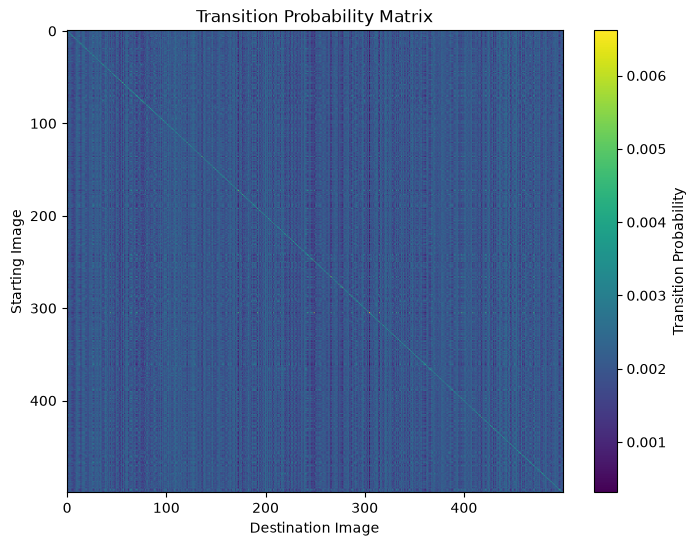

In [316]:
display_transition_probability_heatmap(
    transition_probability_matrix
)

In [317]:
minimum_transition_probability: float = float(
    transition_probability_matrix.min()
)

maximum_transition_probability: float = float(
    transition_probability_matrix.max()
)

minimum_transition_probability_row_sum: float = float(
    transition_probability_row_sums.min()
)

maximum_transition_probability_row_sum: float = float(
    transition_probability_row_sums.max()
)


print("=" * 60)
print("PHASE 8 — TRANSITION PROBABILITY MATRIX SUMMARY")
print("=" * 60)

print(
    f"Number of Images              : "
    f"{transition_probability_matrix.shape[0]}"
)

print(
    f"Transition Matrix Shape       : "
    f"{transition_probability_matrix.shape}"
)

print(
    f"Data Type                    : "
    f"{transition_probability_matrix.dtype}"
)

print(
    f"Minimum Probability          : "
    f"{minimum_transition_probability:.10f}"
)

print(
    f"Maximum Probability          : "
    f"{maximum_transition_probability:.10f}"
)

print(
    f"Minimum Row Sum              : "
    f"{minimum_transition_probability_row_sum:.10f}"
)

print(
    f"Maximum Row Sum              : "
    f"{maximum_transition_probability_row_sum:.10f}"
)

print(
    f"Probabilities Valid          : "
    f"{transition_probabilities_are_valid}"
)

print(
    f"All Rows Sum to One          : "
    f"{all_transition_probability_rows_sum_to_one}"
)

print(
    f"Formula Verification         : "
    f"{np.isclose(
        first_image_to_second_image_probability_manual,
        first_image_to_second_image_probability_matrix
    )}"
)

PHASE 8 — TRANSITION PROBABILITY MATRIX SUMMARY
Number of Images              : 500
Transition Matrix Shape       : (500, 500)
Data Type                    : float32
Minimum Probability          : 0.0003109692
Maximum Probability          : 0.0066147558
Minimum Row Sum              : 0.9999998212
Maximum Row Sum              : 1.0000001192
Probabilities Valid          : True
All Rows Sum to One          : True
Formula Verification         : True


## Phase 8 — Conclusion

In Phase 8, the weighted graph was converted into a transition probability matrix to represent a random walk between the image samples. The transition probability was calculated using:

$$
P_{ij}=\frac{W_{ij}}{q_i}
$$

where (W_{ij}) is the similarity weight between image (i) and image (j), and (q_i) is the weighted degree of image (i):

$$
q_i=\sum_j W_{ij}
$$

The resulting transition probability matrix has a shape of **(500, 500)**, representing the possible transitions between all 500 selected images.

The calculated probabilities ranged from **0.0003109692 to 0.0066147558**, and all values were within the valid probability range of 0 to 1.

The most important property of the transition matrix was also verified. Every row sums to approximately one. The minimum row sum was **0.9999998212** and the maximum was **1.0000001192**. The small differences from exactly 1 are caused by floating-point numerical precision. The `np.allclose()` validation confirmed that all rows correctly sum to one.

The transition probability calculation was independently verified using the connection between Image 1 and Image 2. The graph weight was **0.6415317059**, and the degree of Image 1 was **362.0548706055**. Applying the formula manually produced:

$$
P_{12}
=
\frac{0.6415317059}{362.0548706055}
=
0.0017719185
$$

The implemented matrix produced the same value, confirming that the mathematical formula was correctly implemented.

Therefore, Phase 8 successfully transformed the weighted similarity graph into a **row-stochastic transition probability matrix**. This matrix represents the probability of moving from one image to another and provides the mathematical foundation for the diffusion process.

This phase marks the beginning of the **actual diffusion/random-walk component of the Diffusion Maps method**. In the next phase, the transition matrix will be used to study how information or probability spreads through the image graph.
